# Multi-Layer Neural Network

Goal: move from a single linear layer to a small neural network with hidden layers and activation functions.

Learning Objectives:
- hidden layers
- ReLU
- forward propagation through multiple layers
- model capacity
- train vs validation loss
- overfitting intuition

In [1]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# nonlinear dataset generation

torch.manual_seed(42)


x = torch.linspace(-3, 3, 1000).reshape(-1, 1)

y = (
    0.5 * x**3
    - 2 * x**2
    + x
    + 3
)

y += 0.5 * torch.randn_like(y)

print(x.shape)
print(y.shape)

torch.Size([1000, 1])
torch.Size([1000, 1])


In [2]:
# training test split

dataset = TensorDataset(x, y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [3]:
# define the neural network architecture

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 16), # 1 input feature, 16 output (neurons) features
            nn.ReLU(), # activation function (so linear layers dont collapse into a single linear layer)

            nn.Linear(16, 8), # 16 input features, 8 output (neurons) features
            nn.ReLU(),

            nn.Linear(8, 1) # 8 input features, 1 output (neurons) features
        )

    def forward(self, x):
        return self.network(x)

In [4]:
# instantiate the model and move it to the appropriate device (GPU if available, otherwise CPU)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [5]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [6]:
epochs = 500

for epoch in range(epochs):

    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        predictions = model(xb)

        loss = criterion(predictions, yb)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            predictions = model(xb)

            loss = criterion(predictions, yb)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch    0 | Train Loss: 82.1361 | Val Loss: 89.5097
Epoch   50 | Train Loss: 1.2703 | Val Loss: 1.4187
Epoch  100 | Train Loss: 0.3614 | Val Loss: 0.4377
Epoch  150 | Train Loss: 0.2940 | Val Loss: 0.3167
Epoch  200 | Train Loss: 0.2691 | Val Loss: 0.3240
Epoch  250 | Train Loss: 0.2685 | Val Loss: 0.3017
Epoch  300 | Train Loss: 0.2672 | Val Loss: 0.3009
Epoch  350 | Train Loss: 0.2661 | Val Loss: 0.3018
Epoch  400 | Train Loss: 0.2622 | Val Loss: 0.3127
Epoch  450 | Train Loss: 0.2649 | Val Loss: 0.3132


In [7]:
# training loss improving while validation loss increasing is a sign of overfitting

In [13]:
x_plot = torch.linspace(-3, 3, 500).reshape(-1, 1) # dense set of values covering same range as dataset

In [15]:
# using trained model to predict x_plot

model.eval()

# compute on gpu
with torch.no_grad():
    x_plot_gpu = x_plot.to(device)
    y_plot = model(x_plot_gpu)

# output to cpu for matplotlib to plot
y_plot = y_plot.cpu()

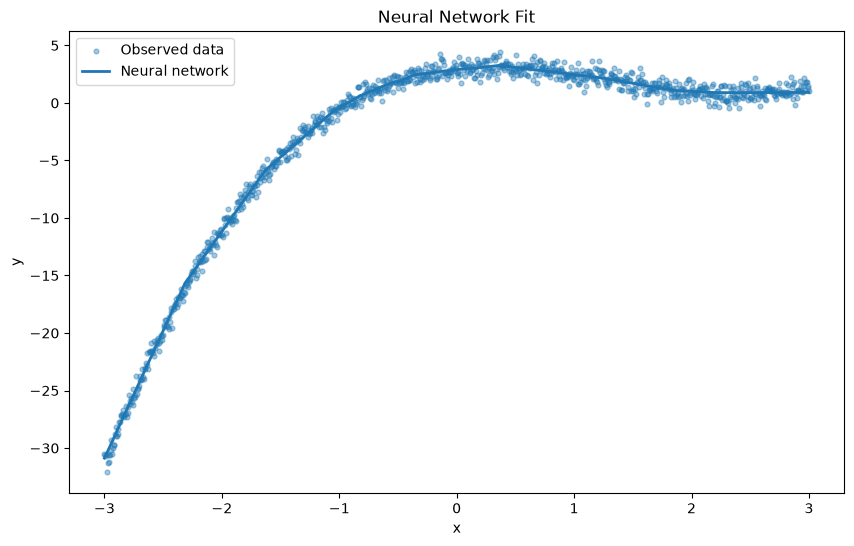

In [16]:
# neural network fit plot, dots = observed data, line = neural net output

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    x.numpy(),
    y.numpy(),
    s=12,
    alpha=0.4,
    label="Observed data"
)

plt.plot(
    x_plot.numpy(),
    y_plot.numpy(),
    linewidth=2,
    label="Neural network"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural Network Fit")
plt.legend()

plt.show()